# Nelson-Siegel Factors of the US Treasury Yield Curve, 1982–2026

This notebook fits the Nelson-Siegel model to the US Treasury yield curve every month since January 1982, with a fixed decay rate λ (Diebold & Li, 2006). It tracks the three factors (level, slope and curvature), checks that they carry their economic meaning, and shows where the model fits well and where it struggles.

**Contents:** 1. Setup · 2. Data · 3. Fit on one month · 4. Fit on every month · 5. Factors over time · 6. Economic meaning of the factors · 7. Key dates · 8. Key findings

## 1. Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from fredapi import Fred
from nelson_siegel_svensson.calibrate import betas_ns_ols

load_dotenv()
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

## 2. Data: US Treasury yields from the FRED API

Eight constant-maturity Treasury yields, from 3 months to 10 years, converted to monthly averages. These maturities are available without gaps since 1982.

In [3]:
# FRED code -> maturity in years
SERIES = {"DGS3MO": 0.25, "DGS6MO": 0.5, "DGS1": 1, "DGS2": 2,
          "DGS3": 3, "DGS5": 5, "DGS7": 7, "DGS10": 10}


def download_series(series, obs_start="1982-01-01", obs_end=None):
    """Télécharge les taux du Trésor depuis FRED et renvoie les moyennes mensuelles."""
    yields = {}
    for series_id in series:
        try:
            data = fred.get_series(series_id, observation_start=obs_start, observation_end=obs_end)
            if data is not None and not data.empty:
                yields[series_id] = data
        except Exception as e:
            print(f"[ERROR] {series_id}: {e}")

    if not yields:
        raise ValueError("Aucune donnée téléchargée.")

    monthly = pd.DataFrame(yields).resample("MS").mean().dropna()

    # Keep complete months only
    current_month = pd.Timestamp.today().to_period("M").to_timestamp()
    return monthly[monthly.index < current_month]


yields = download_series(SERIES)
print(yields.shape)
yields.tail()



(537, 8)


,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10
2026-05-01,3.685500,3.765000,3.792000,3.995000,4.042000,4.145000,4.308500,4.484000
2026-06-01,3.810952,3.870476,3.909524,4.112857,4.146667,4.210000,4.330952,4.470476
2026-07-01,3.866818,4.001818,4.050909,4.222727,4.256818,4.330909,4.455455,4.599545
2026-08-01,3.876667,3.967619,4.031429,4.216190,4.282381,4.384286,4.524762,4.684286
2026-09-01,4.092857,4.178571,4.365238,4.651429,4.734762,4.802857,4.890952,4.989048


In [4]:
yields.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 537 entries, 1982-01-01 to 2026-09-01
Freq: MS
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS3MO  537 non-null    float64
 1   DGS6MO  537 non-null    float64
 2   DGS1    537 non-null    float64
 3   DGS2    537 non-null    float64
 4   DGS3    537 non-null    float64
 5   DGS5    537 non-null    float64
 6   DGS7    537 non-null    float64
 7   DGS10   537 non-null    float64
dtypes: float64(8)
memory usage: 37.8 KB


## 3. Fitting Nelson-Siegel on one month

With λ fixed, fitting the model on one curve is a simple linear regression: the three shapes (level, slope, curvature) are known in advance, and the model only estimates their weights β₀, β₁ and β₂. The fit quality is measured by the RMSE, in basis points (1 bp = 0.01%).

In [5]:
# λ fixed as in Diebold & Li (2006): 0.0609 in months, i.e. 0.7308 in years
LAMBDA = 0.7308
TAU = 1 / LAMBDA          # the library uses τ = 1/λ

# Maturities in years, in column order
t = np.array(list(SERIES.values()))


def fit_ns(y, tau=TAU):
    """Ajuste Nelson-Siegel (λ fixé) sur une courbe et renvoie la courbe et l'erreur en points de base."""
    curve, _ = betas_ns_ols(tau, t, y)
    rmse_bp = np.sqrt(np.mean((y - curve(t)) ** 2)) * 100
    return curve, rmse_bp


# Fit on one month
date = "2020-01-01"
y = yields.loc[date].values
curve, rmse_bp = fit_ns(y)

print(f"β0 (niveau)    = {curve.beta0:.2f}")
print(f"β1 (pente)     = {curve.beta1:.2f}")
print(f"β2 (courbure)  = {curve.beta2:.2f}")
print(f"Erreur (RMSE)  = {rmse_bp:.1f} points de base")


β0 (niveau)    = 1.87
β1 (pente)     = -0.25
β2 (courbure)  = -0.83
Erreur (RMSE)  = 2.5 points de base


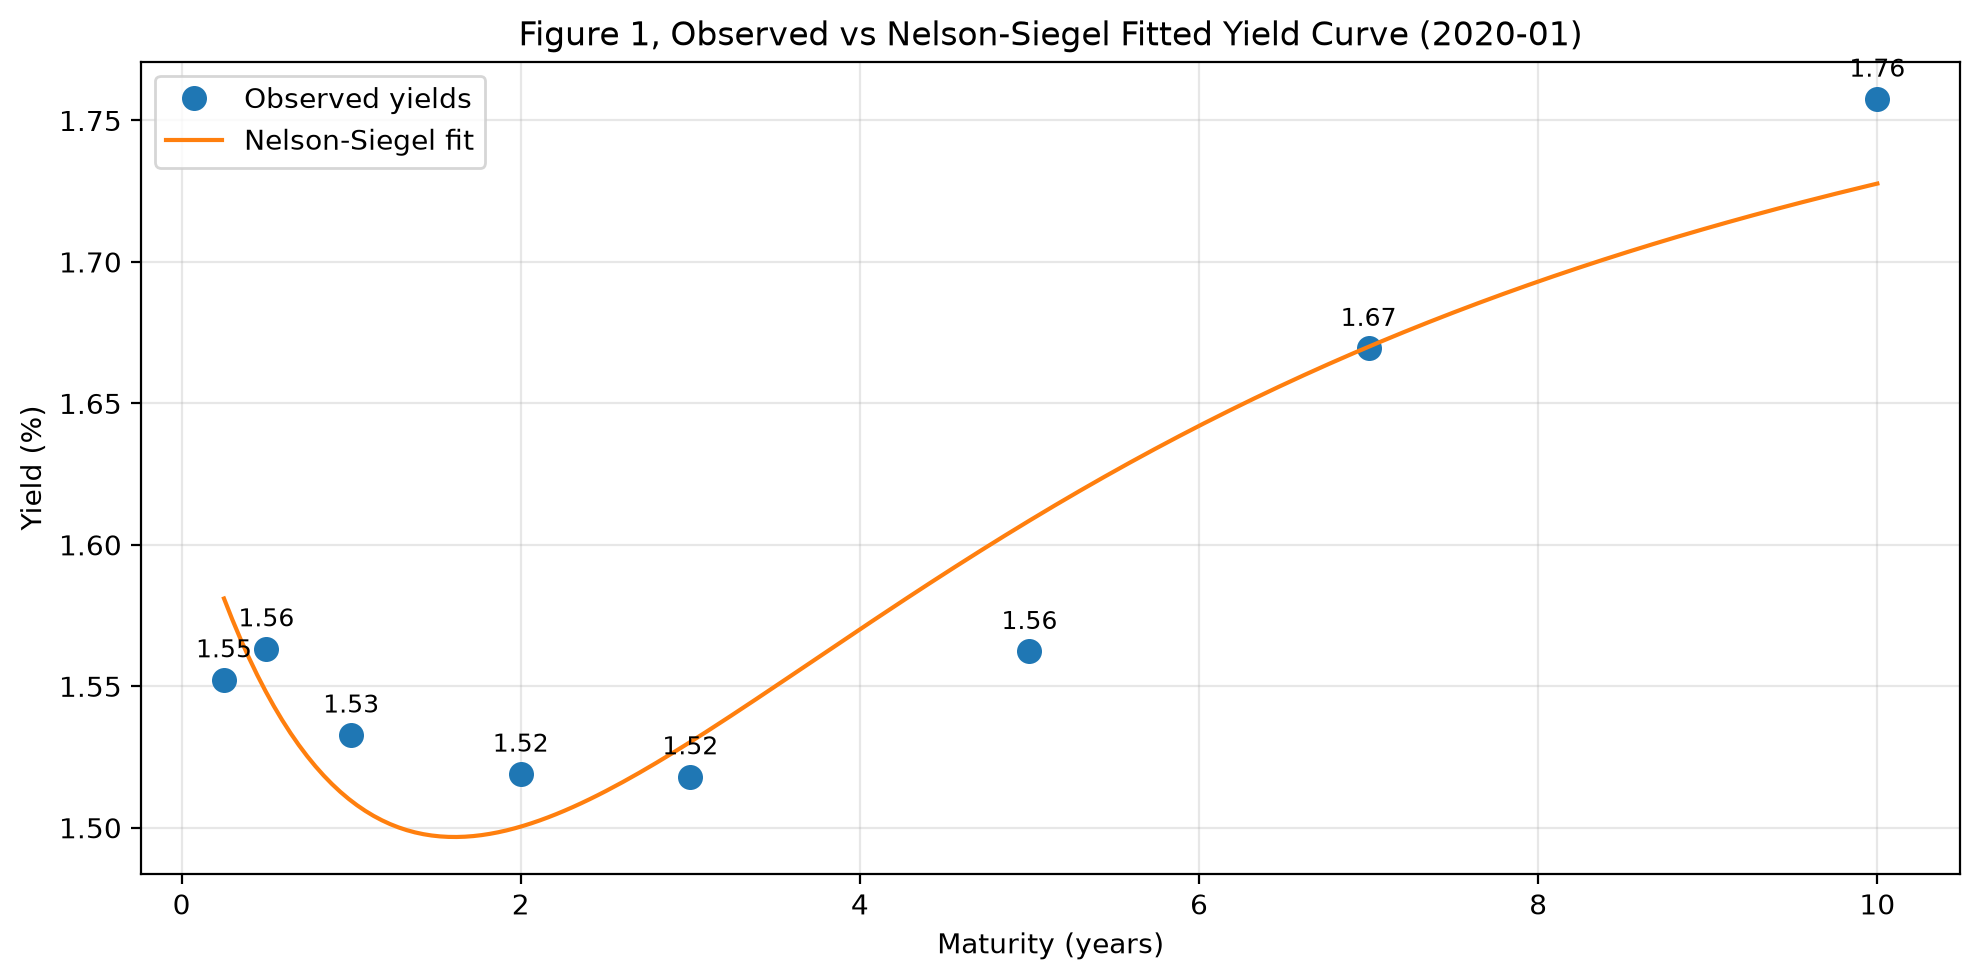

In [6]:
def plot_ns_fit(t, y, curve, date, fig_num=1):
    """Trace les taux observés et la courbe Nelson-Siegel ajustée."""
    fig, ax = plt.subplots(figsize=(10, 5), dpi=200)

    grid = np.linspace(0.25, 10, 200)
    ax.plot(t, y, marker='o', linestyle='none', markersize=8, label='Observed yields')
    ax.plot(grid, curve(grid), label='Nelson-Siegel fit')

    # Annotate each observed yield, slightly above the point
    
    for xi, yi in zip(t, y):
        ax.annotate(f"{yi:.2f}", (xi, yi), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=9)

    ax.set_xlabel('Maturity (years)')
    ax.set_ylabel('Yield (%)')
    ax.set_title(f"Figure {fig_num}, Observed vs Nelson-Siegel Fitted Yield Curve ({date[:7]})")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


fig = plot_ns_fit(t, y, curve, date)
plt.show()

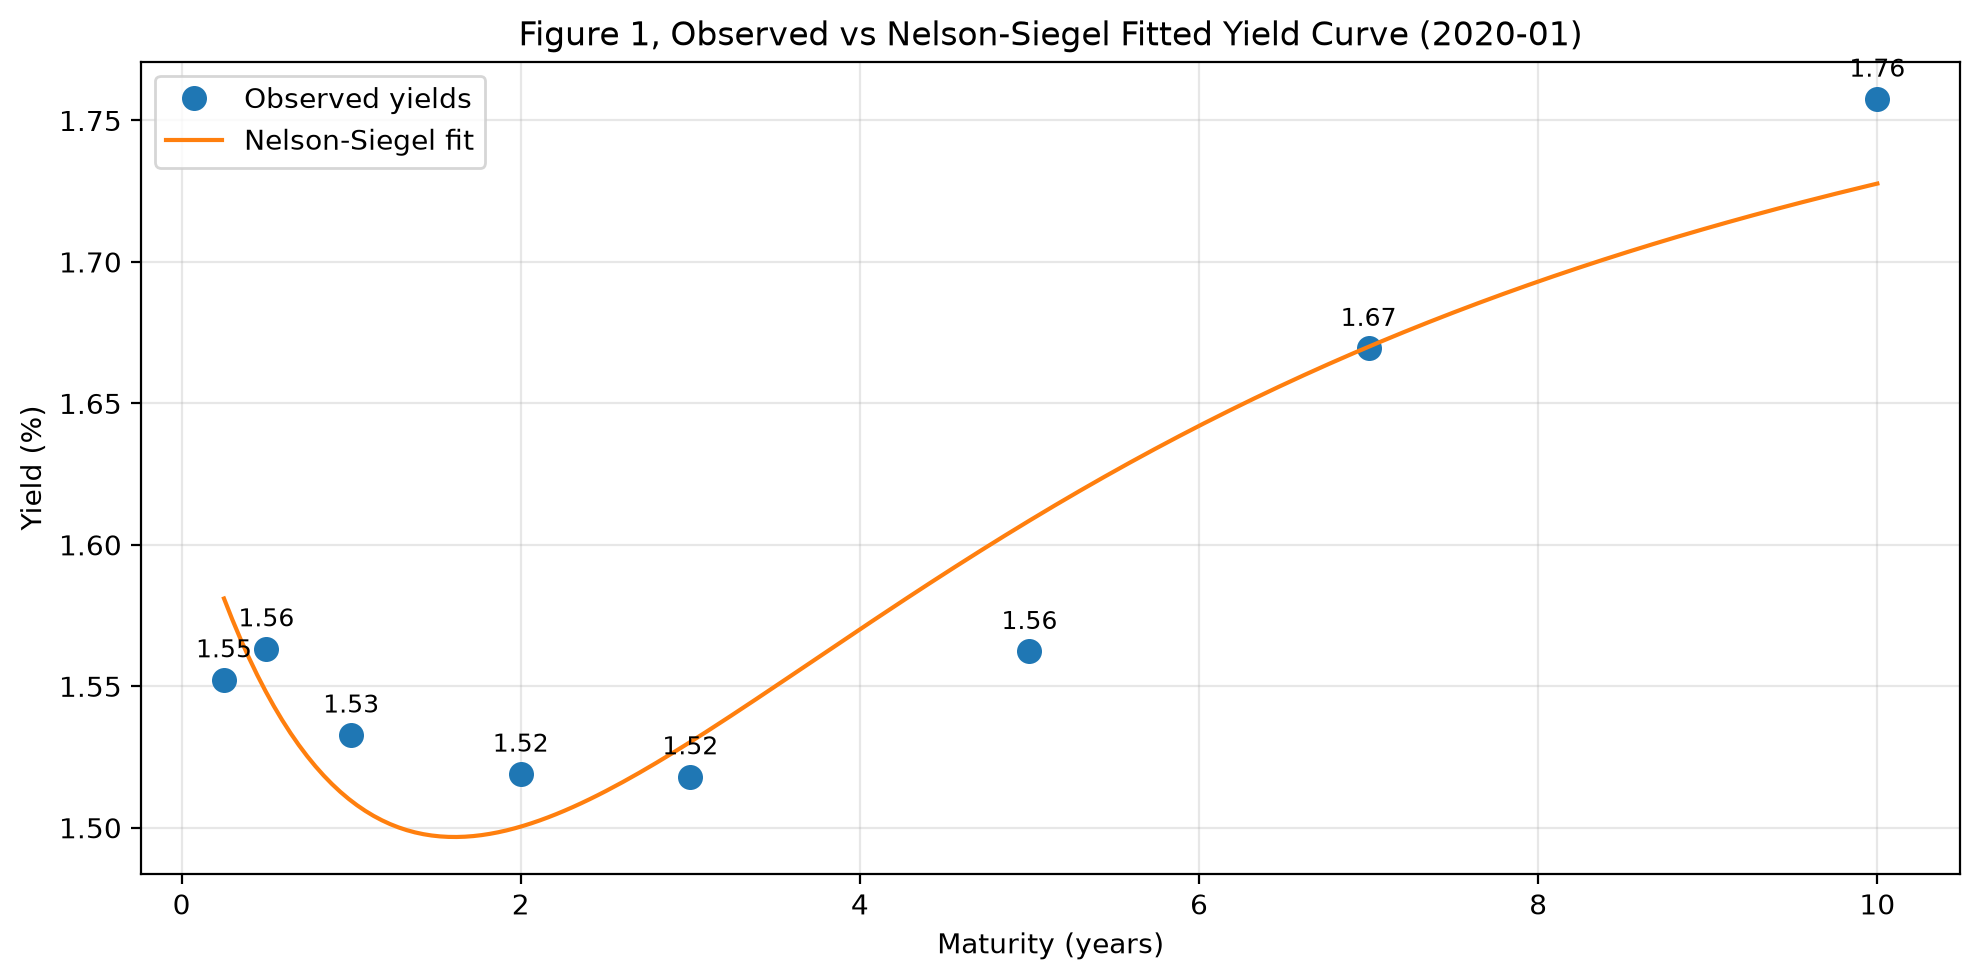

In [7]:
fig = plot_ns_fit(t, y, curve, date)
fig.savefig("assets/figure1_ns_fit_2020.png", bbox_inches="tight")
plt.show()

### Interpretation (January 2020)

The Nelson-Siegel model fits the January 2020 curve very well, with a **root mean squared error (RMSE) of 2.5 basis points**. The RMSE measures the typical gap between the observed yields and the model's yields, expressed in the same unit as the yields. 2.5 basis points equal 0.025 percentage points: in other words, the fitted curve typically deviates from the actual yields by about 0.025%.

- **Level (β₀ = 1.87):** the long-term yield implied by the model, consistent with a 10-year yield of 1.76% that is still rising.
- **Slope (β₁ = −0.25):** the short end of the fitted curve, β₀ + β₁ = 1.62%, is close to the observed 3-month yield of 1.55%. The negative sign means that short-term yields sit below long-term yields.
- **Curvature (β₂ = −0.83):** a negative curvature creates a **trough** instead of a hump. This is what the data show: the 2-year and 3-year yields are lower than both the short-term and the long-term yields, giving the curve a "U" shape, typical of an economy where markets expect rate cuts.

**Limit:** with only three factors and a fixed λ, the model cannot capture every local move. The largest gap is at the 5-year maturity (about 5 basis points), a small error that looks large only because the y-axis spans just 25 basis points.

## 4. Fitting the model on every month since 1982

The same regression is repeated on each of the 537 months, keeping β₀, β₁, β₂ and the RMSE for each one.

In [8]:
def fit_all_months(yields, tau=TAU):
    """Ajuste Nelson-Siegel sur chaque mois et renvoie les facteurs et l'erreur d'ajustement."""
    rows = []
    for date, row in yields.iterrows():
        curve, rmse_bp = fit_ns(row.values, tau)
        rows.append({
            "date": date,
            "beta0": curve.beta0,
            "beta1": curve.beta1,
            "beta2": curve.beta2,
            "rmse_bp": rmse_bp,
        })
    return pd.DataFrame(rows).set_index("date")

In [9]:
factors = fit_all_months(yields)
print(factors.shape)
factors.describe().round(2)

(537, 4)


,beta0,beta1,beta2,rmse_bp
count,537.00,537.00,537.00,537.00
mean,5.70,-1.97,-1.18,5.18
std,2.84,1.67,2.33,3.16
min,0.84,-5.09,-6.52,0.94
25%,3.63,-3.29,-2.65,3.00
50%,5.04,-1.96,-1.02,4.43
75%,7.53,-0.66,0.50,6.37
max,14.14,2.39,7.42,26.84


In [10]:
inverted_share = (factors["beta1"] > 0).mean() * 100
print(f"Months with an inverted curve (β1 > 0): {inverted_share:.1f}%")

Months with an inverted curve (β1 > 0): 11.5%


In [11]:
factors.sort_values("rmse_bp", ascending=False).head(5).round(2)

,beta0,beta1,beta2,rmse_bp
date,,,,
1982-09-01,11.71,-4.00,7.42,26.84
1982-08-01,12.68,-4.13,6.28,23.94
2008-11-01,4.36,-3.90,-3.71,20.13
1982-01-01,14.14,-1.33,4.01,18.89
2008-10-01,4.70,-3.74,-3.82,17.80


### Results: Nelson-Siegel factors, January 1982 to September 2026

The model was fitted on each of the 537 months with a fixed λ = 0.7308 (Diebold & Li, 2006).

**Fit quality.** The median RMSE is **4.4 basis points (0.044%)**, and three months out of four stay below **6.4 basis points (0.064%)**: three factors are enough to describe the US yield curve over 44 years.

**Level (β₀, in %).** It ranges from **14.14%** to **0.84%**, tracing the whole history of US rates, from the Volcker era of the early 1980s to the near-zero rates of the following decades.

**Slope (β₁, in percentage points).** Its mean is **−1.97 points**, and it is negative in at least 75% of months: the curve is usually upward-sloping, reflecting the term premium. The curve is inverted (β₁ > 0) in only **11.5% of months**, about one month in nine, which explains why each inversion draws so much attention.

**Curvature (β₂, in percentage points).** It ranges from **−6.52** to **+7.42 points** and is the most volatile factor relative to its mean, a classic finding: curvature is harder to estimate and noisier than level and slope.

**Where the model struggles.** The five worst fits all fall in two crisis periods:

| Month | RMSE (bp) | RMSE (%) | Context |
|-------|-----------|----------|---------|
| September 1982 | 26.84 | 0.268 | Sharp Fed easing at the end of the 1981–82 recession |
| August 1982 | 23.94 | 0.239 | Same period |
| November 2008 | 20.13 | 0.201 | Flight to safety after Lehman Brothers' collapse |
| January 1982 | 18.89 | 0.189 | Volcker-era record yields |
| October 2008 | 17.80 | 0.178 | Same crisis |

In both periods, the short end of the curve moved very fast. With a fixed λ, the model's hump cannot shift to follow these extreme shapes: this is the price of stable, comparable factors over time.

## 5. Factors and fit error over time

In [12]:
# Official US recessions (NBER, peak to trough)

RECESSIONS = [("1981-07-01", "1982-11-30"), ("1990-07-01", "1991-03-31"),
              ("2001-03-01", "2001-11-30"), ("2007-12-01", "2009-06-30"),
              ("2020-02-01", "2020-04-30")]


def shade_recessions(ax, start):
    """Grise les périodes de récession sur un graphique."""
    for a, b in RECESSIONS:
        ax.axvspan(max(pd.Timestamp(a), start), pd.Timestamp(b), color="grey", alpha=0.25, lw=0)


def plot_factors(factors, fig_num=2):
    """Trace les trois facteurs de Nelson-Siegel dans le temps."""
    fig, axes = plt.subplots(3, 1, figsize=(12, 9), dpi=200, sharex=True)
    specs = [("beta0", "Level (β₀, %)", "tab:blue"),
             ("beta1", "Slope (β₁, pp)", "tab:orange"),
             ("beta2", "Curvature (β₂, pp)", "tab:purple")]

    for ax, (col, label, color) in zip(axes, specs):
        ax.plot(factors.index, factors[col], color=color)
        shade_recessions(ax, factors.index[0])
        ax.axhline(0, color="black", lw=0.8, ls="--")
        ax.set_ylabel(label)
        ax.grid(alpha=0.3)

    
    # Highlight the months when the curve is inverted
       
    inverted = factors["beta1"] > 0
    axes[1].fill_between(factors.index, 0, factors["beta1"], where=inverted,
                         color="tab:red", alpha=0.4, label="Inverted curve (β₁ > 0)")
    axes[1].legend(loc="lower left")

    axes[0].set_title(f"Figure {fig_num}, Nelson-Siegel Factors of the US Yield Curve (grey = NBER recessions)")
    axes[-1].set_xlabel("Date")
    fig.tight_layout()
    return fig


def plot_fit_error(factors, n_worst=5, fig_num=3):
    """Trace l'erreur d'ajustement dans le temps et signale les pires mois."""
    fig, ax = plt.subplots(figsize=(12, 4), dpi=200)
    ax.plot(factors.index, factors["rmse_bp"], color="tab:blue", lw=1)
    shade_recessions(ax, factors.index[0])

    median = factors["rmse_bp"].median()
    ax.axhline(median, color="black", ls="--", lw=1, label=f"Median: {median:.1f} bp")

    worst = factors.nlargest(n_worst, "rmse_bp")
    ax.scatter(worst.index, worst["rmse_bp"], color="tab:red", zorder=5, label=f"{n_worst} worst fits")
    for date, value in worst["rmse_bp"].items():
        ax.annotate(date.strftime("%b %Y"), (date, value), textcoords="offset points",
                    xytext=(6, 4), fontsize=8)

    ax.set_xlabel("Date")
    ax.set_ylabel("RMSE (basis points)")
    ax.set_title(f"Figure {fig_num}, Nelson-Siegel Fit Error Over Time (grey = NBER recessions)")
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig

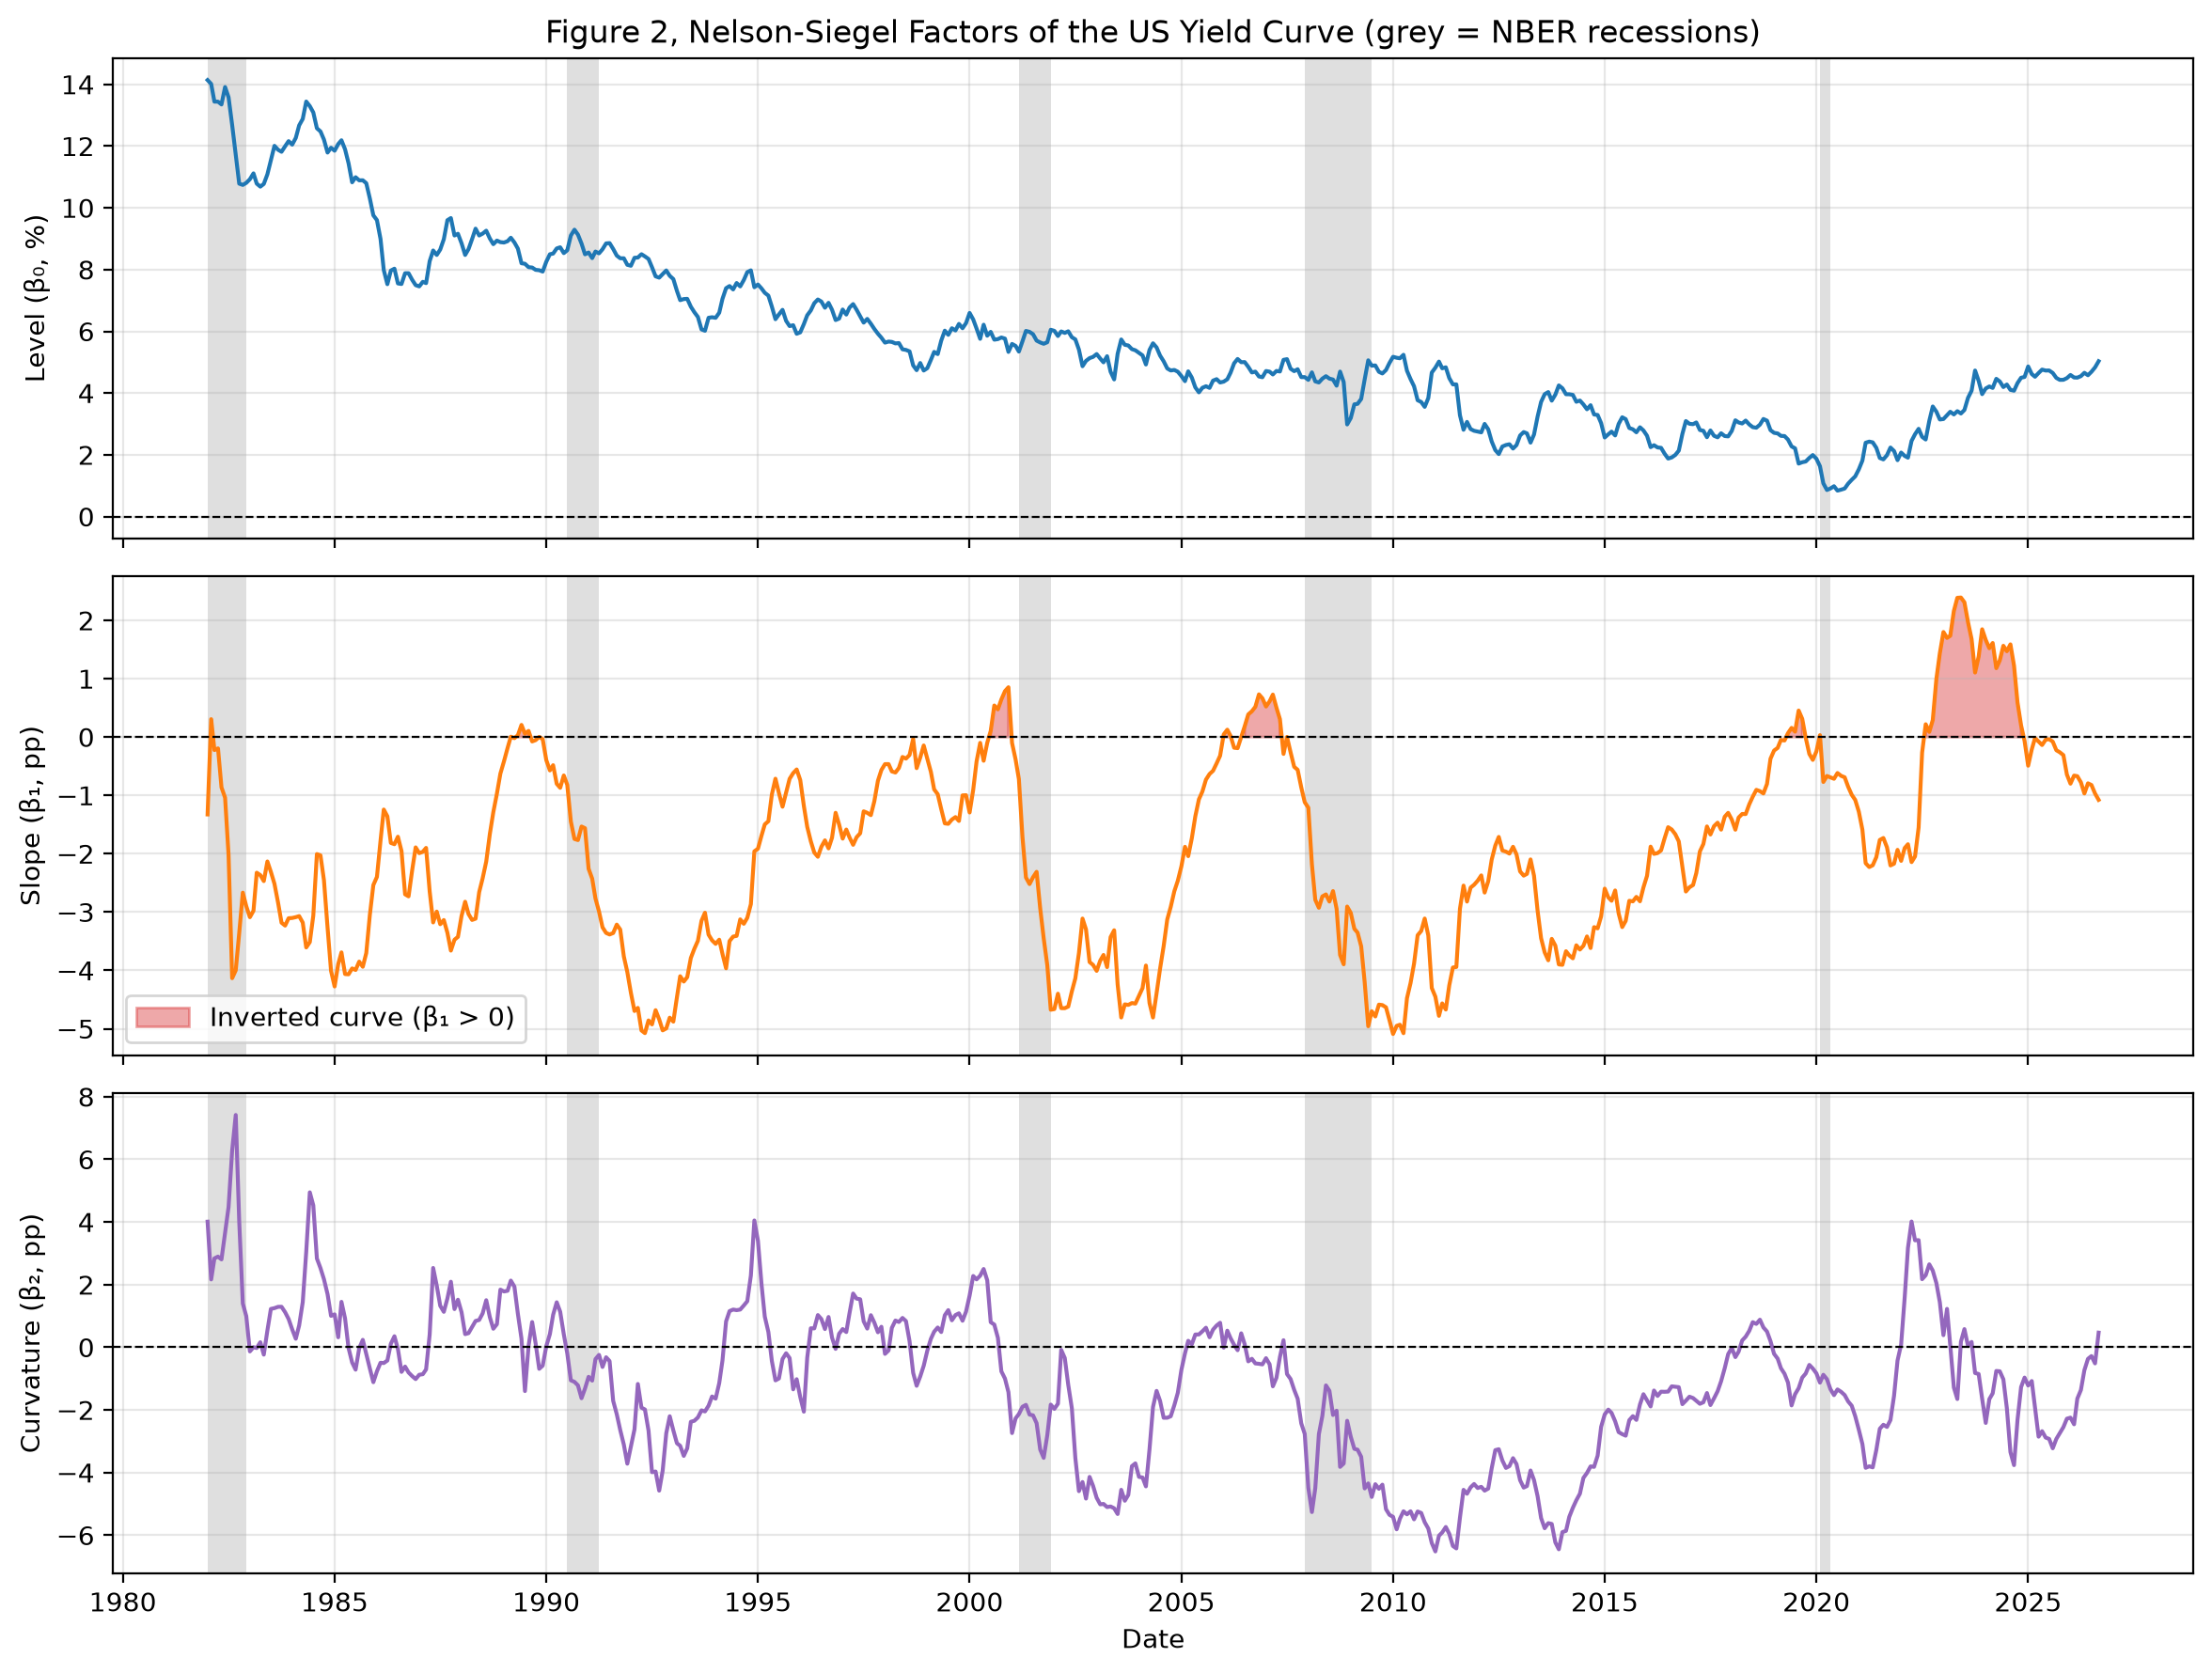

In [13]:
fig = plot_factors(factors)
fig.savefig("assets/figure2_factors.png", bbox_inches="tight")
plt.show()

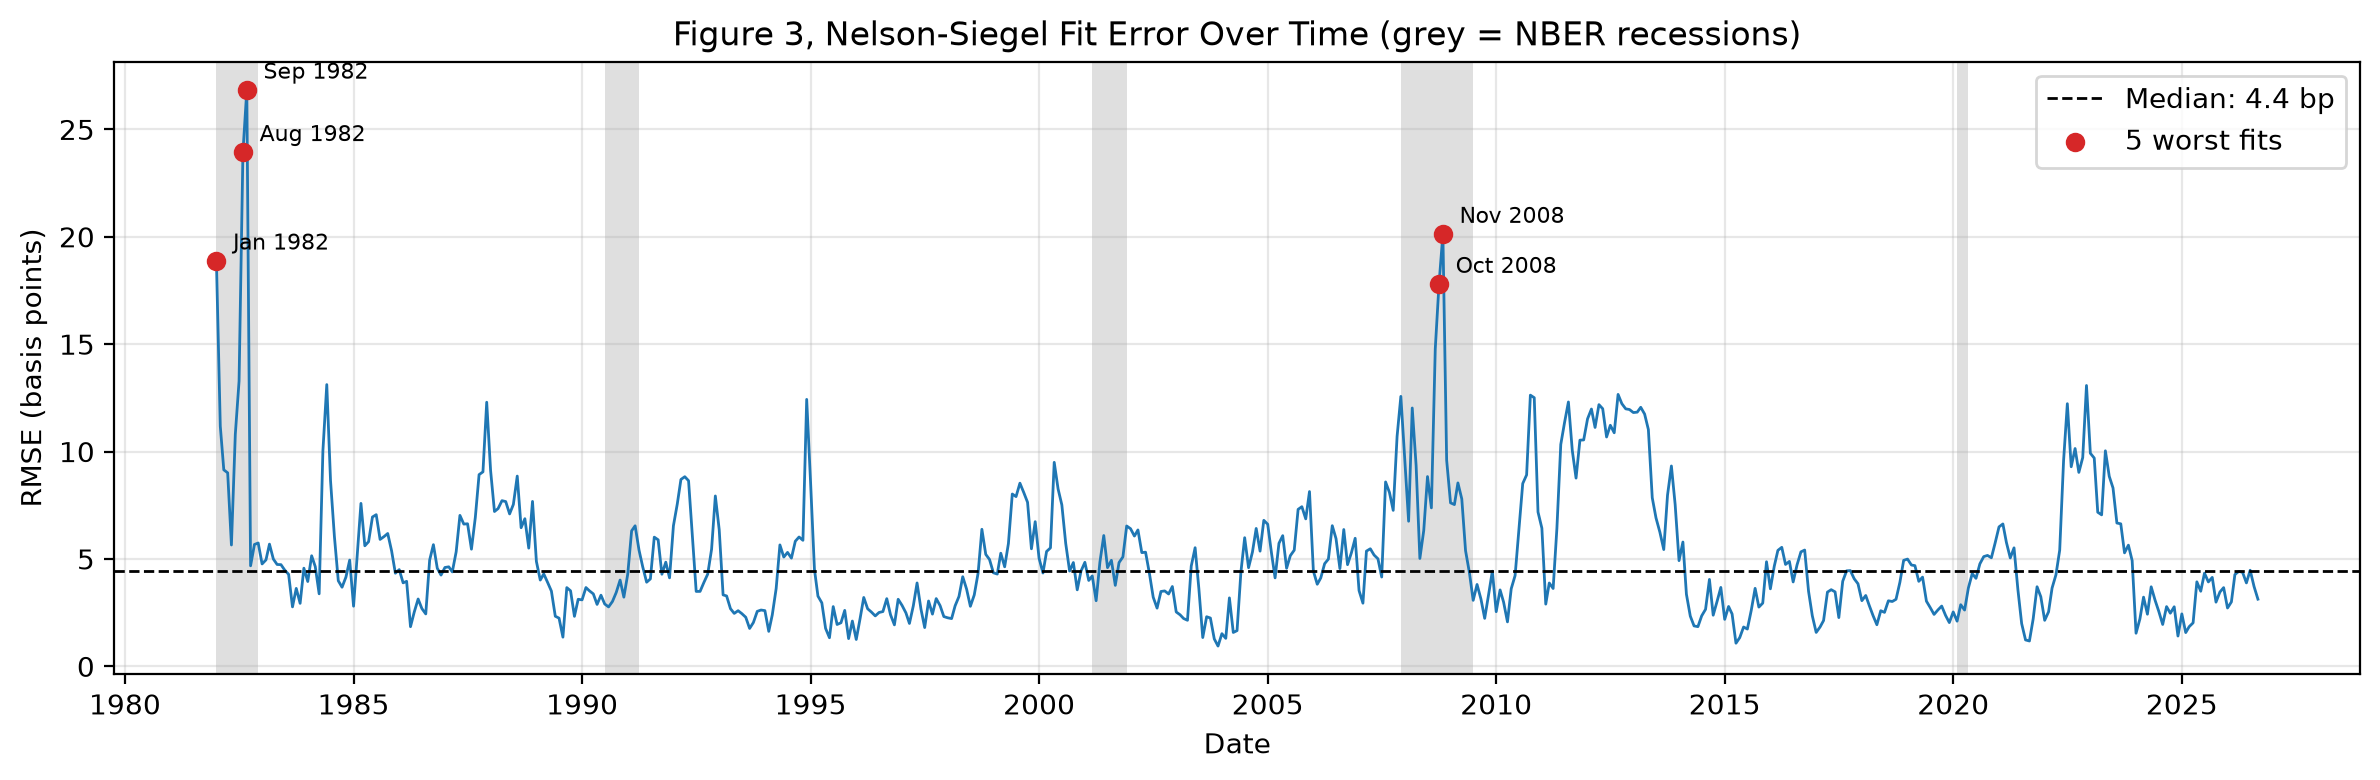

In [14]:
fig = plot_fit_error(factors)
fig.savefig("assets/figure3_fit_error.png", bbox_inches="tight")
plt.show()

**What the charts add.**
- **Inversions lead recessions:** the red areas appear in 2000, 2006–2007 and 2019, just before the grey recession bands. Right after each recession, the slope plunges to around −4 or −5 points as the Fed cuts rates. The 2022–2024 inversion, the deepest of the period, has not been followed by a recession.
- **The level has risen again since 2022**, from about 1% to about 5%, after four decades of decline.
- **A third weak spot for the model:** from 2011 to 2013, fit errors reach 10 to 12 basis points (0.10% to 0.12%). Short rates were stuck at zero, and a fixed λ struggles with a curve pinned to the floor at the short end. A smaller spike appears during the fast rate hikes of 2022–2023.

## 6. Economic meaning of the factors

Each factor is compared with a simple measure computed directly from observed yields: the 10-year yield for the level, the 10Y − 3M spread for the slope, and the butterfly (2 × 2Y − 3M − 10Y) for the curvature.

In [15]:
def compute_proxies(yields):
    """Calcule les mesures observées du niveau, de la pente et de la courbure."""
    return pd.DataFrame({
        "level": yields["DGS10"],
        "slope": yields["DGS10"] - yields["DGS3MO"],
        "curvature": 2 * yields["DGS2"] - yields["DGS3MO"] - yields["DGS10"],
    })


def plot_factor_checks(factors, proxies, fig_num=4):
    """Compare chaque facteur de Nelson-Siegel à sa mesure observée."""
    pairs = [
        (factors["beta0"], proxies["level"], "Level: β₀ (%)", "10-year yield (%)", "tab:blue"),
        (-factors["beta1"], proxies["slope"], "Slope: −β₁ (pp)", "10Y − 3M spread (pp)", "tab:orange"),
        (factors["beta2"], proxies["curvature"], "Curvature: β₂ (pp)", "2×2Y − 3M − 10Y (pp)", "tab:purple"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=200)
    for ax, (factor, proxy, xlabel, ylabel, color) in zip(axes, pairs):
        corr = factor.corr(proxy)
        ax.scatter(factor, proxy, s=8, alpha=0.5, color=color)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"Correlation = {corr:.2f}")
        ax.grid(alpha=0.3)

    fig.suptitle(f"Figure {fig_num}, Nelson-Siegel Factors vs Observed Yield Curve Measures")
    fig.tight_layout()
    return fig

In [16]:
proxies = compute_proxies(yields)

checks = pd.DataFrame({
    "Level (β₀ vs 10Y)": [factors["beta0"].corr(proxies["level"])],
    "Slope (−β₁ vs 10Y − 3M)": [(-factors["beta1"]).corr(proxies["slope"])],
    "Curvature (β₂ vs butterfly)": [factors["beta2"].corr(proxies["curvature"])],
}, index=["Correlation"]).round(3)
checks

,Level (β₀ vs 10Y),Slope (−β₁ vs 10Y − 3M),Curvature (β₂ vs butterfly)
Correlation,0.988,0.992,0.998


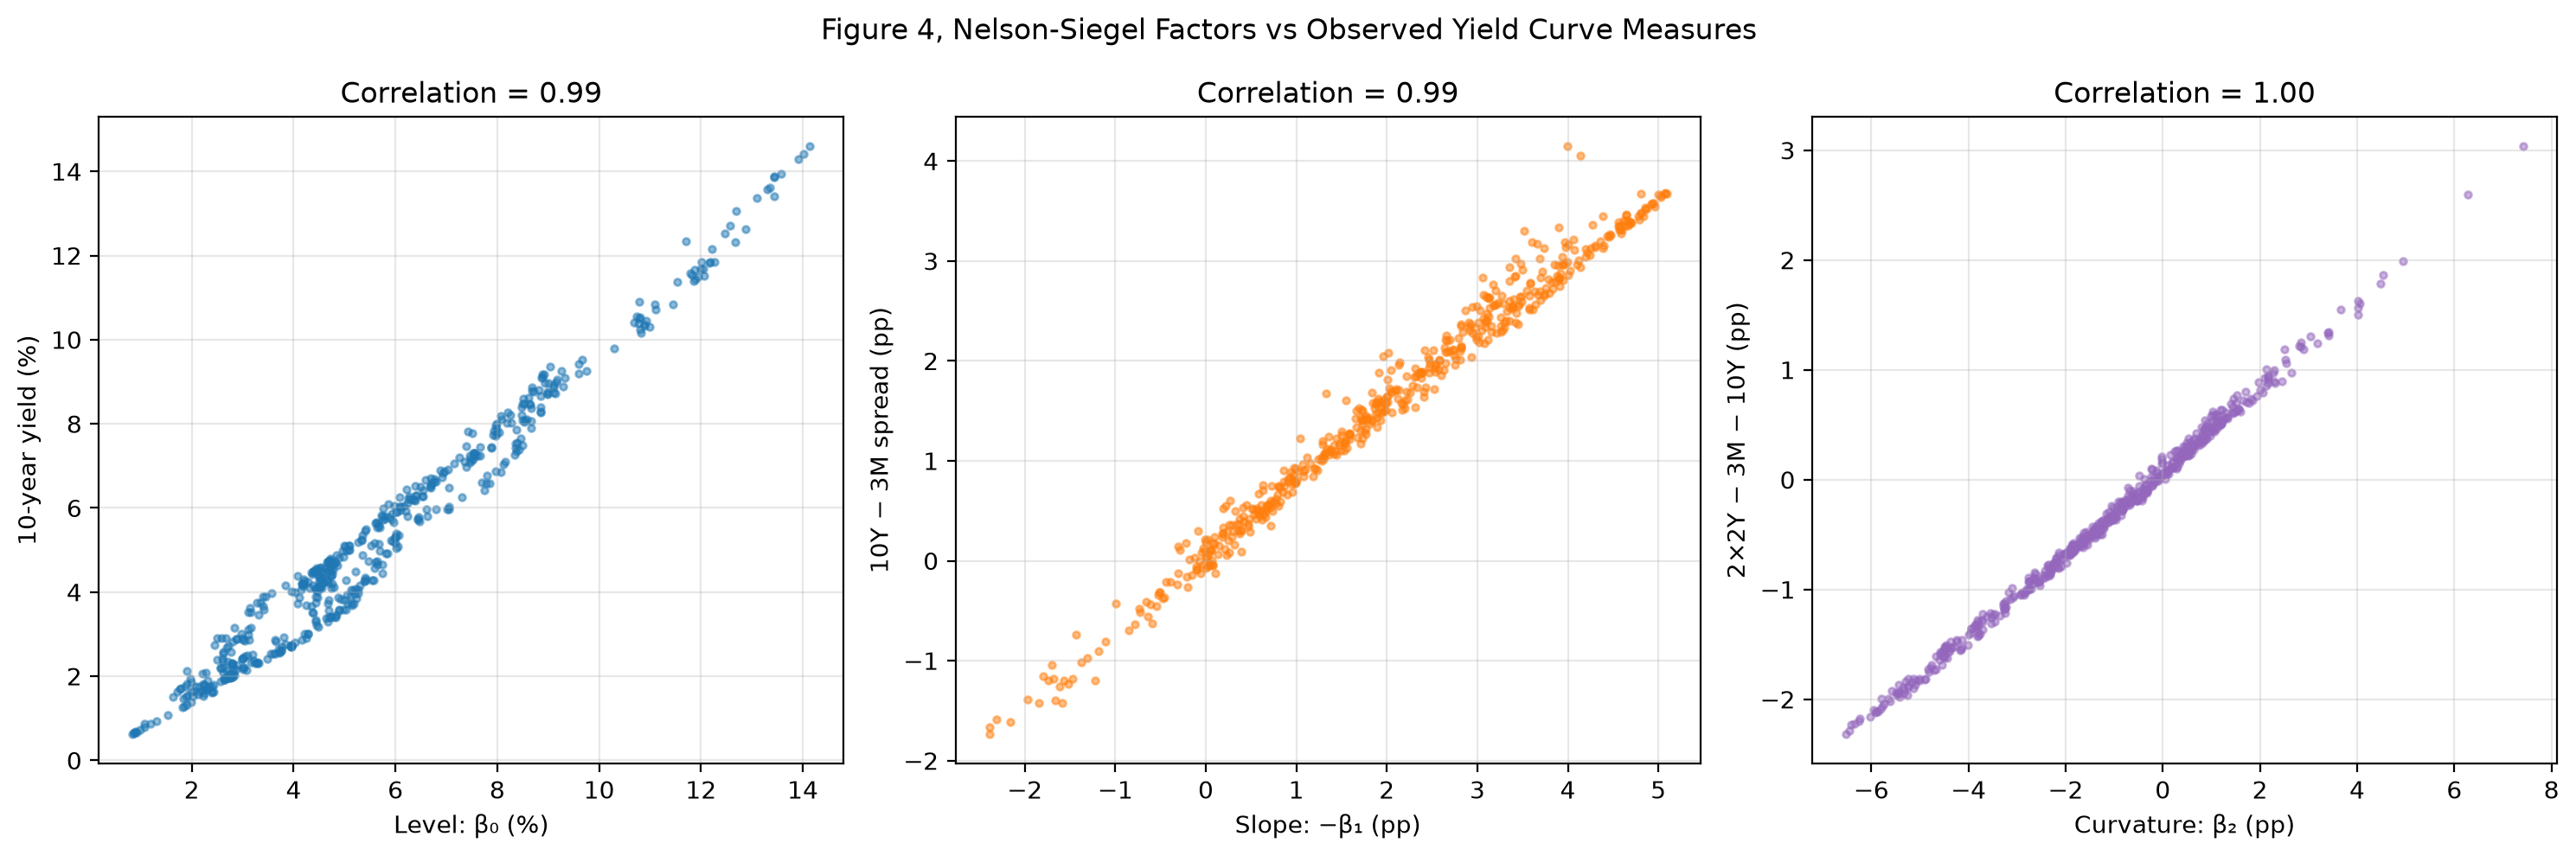

In [17]:
fig = plot_factor_checks(factors, proxies)
fig.savefig("assets/figure4_factor_checks.png", bbox_inches="tight")
plt.show()

### Do the factors mean what we think? (Figure 4)

Each factor is compared with a simple measure computed directly from observed yields:

| Factor | Observed measure | Correlation |
|--------|------------------|-------------|
| Level (β₀) | 10-year yield | 0.988 |
| Slope (−β₁) | 10Y − 3M spread | 0.992 |
| Curvature (β₂) | Butterfly: 2 × 2Y − 3M − 10Y | 0.998 |

All three correlations exceed 0.98: **β₀, β₁ and β₂ do capture the level, slope and curvature of the curve.**

**Caveat:** with a fixed λ, each β is a linear combination of the eight observed yields, and so is each measure. These high correlations therefore confirm the economic meaning of the factors, but they are partly mechanical and should not be read as predictive power. The curvature match is especially tight because, with λ = 0.7308, the hump of the model peaks around 2.5 years, close to the 2-year yield used in the butterfly.

**Reading the charts.** The level chart shows two parallel bands: β₀ is the very long-term yield, so the 10-year yield sits further below it when the curve is steep. The slope points are aligned but not on a perfect diagonal, because the 3-month and 10-year maturities are not exactly the two ends of the model's curve.

## 7. Observed vs fitted curves at key dates

Six months, each telling a different story: the Volcker era, two inversions before recessions, the Lehman Brothers collapse, the zero lower bound, and the deepest inversion of the period.

In [18]:
KEY_DATES = {
    "1982-09-01": "Volcker era (worst fit)",
    "2000-11-01": "Inversion before the dot-com bust",
    "2006-12-01": "Inversion before the 2008 crisis",
    "2008-11-01": "After Lehman Brothers",
    "2012-06-01": "Short rates stuck at zero",
    "2023-06-01": "Deepest inversion",
}


def plot_key_dates(yields, key_dates, fig_num=5):
    """Compare la courbe observée et la courbe Nelson-Siegel à plusieurs dates clés."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=200)
    grid = np.linspace(0.25, 10, 200)

    for ax, (date, label) in zip(axes.flat, key_dates.items()):
        y_obs = yields.loc[date].values
        curve, rmse_bp = fit_ns(y_obs)

        ax.plot(t, y_obs, marker='o', linestyle='none', markersize=6, label='Observed yields')
        ax.plot(grid, curve(grid), label='Nelson-Siegel fit')
        ax.set_title(f"{label} ({date[:7]})\nRMSE = {rmse_bp:.1f} bp", fontsize=10)
        ax.set_xlabel('Maturity (years)')
        ax.set_ylabel('Yield (%)')
        ax.grid(alpha=0.3)

    axes.flat[0].legend(fontsize=8)
    fig.suptitle(f"Figure {fig_num}, Observed vs Nelson-Siegel Fitted Curves at Key Dates")
    fig.tight_layout()
    return fig

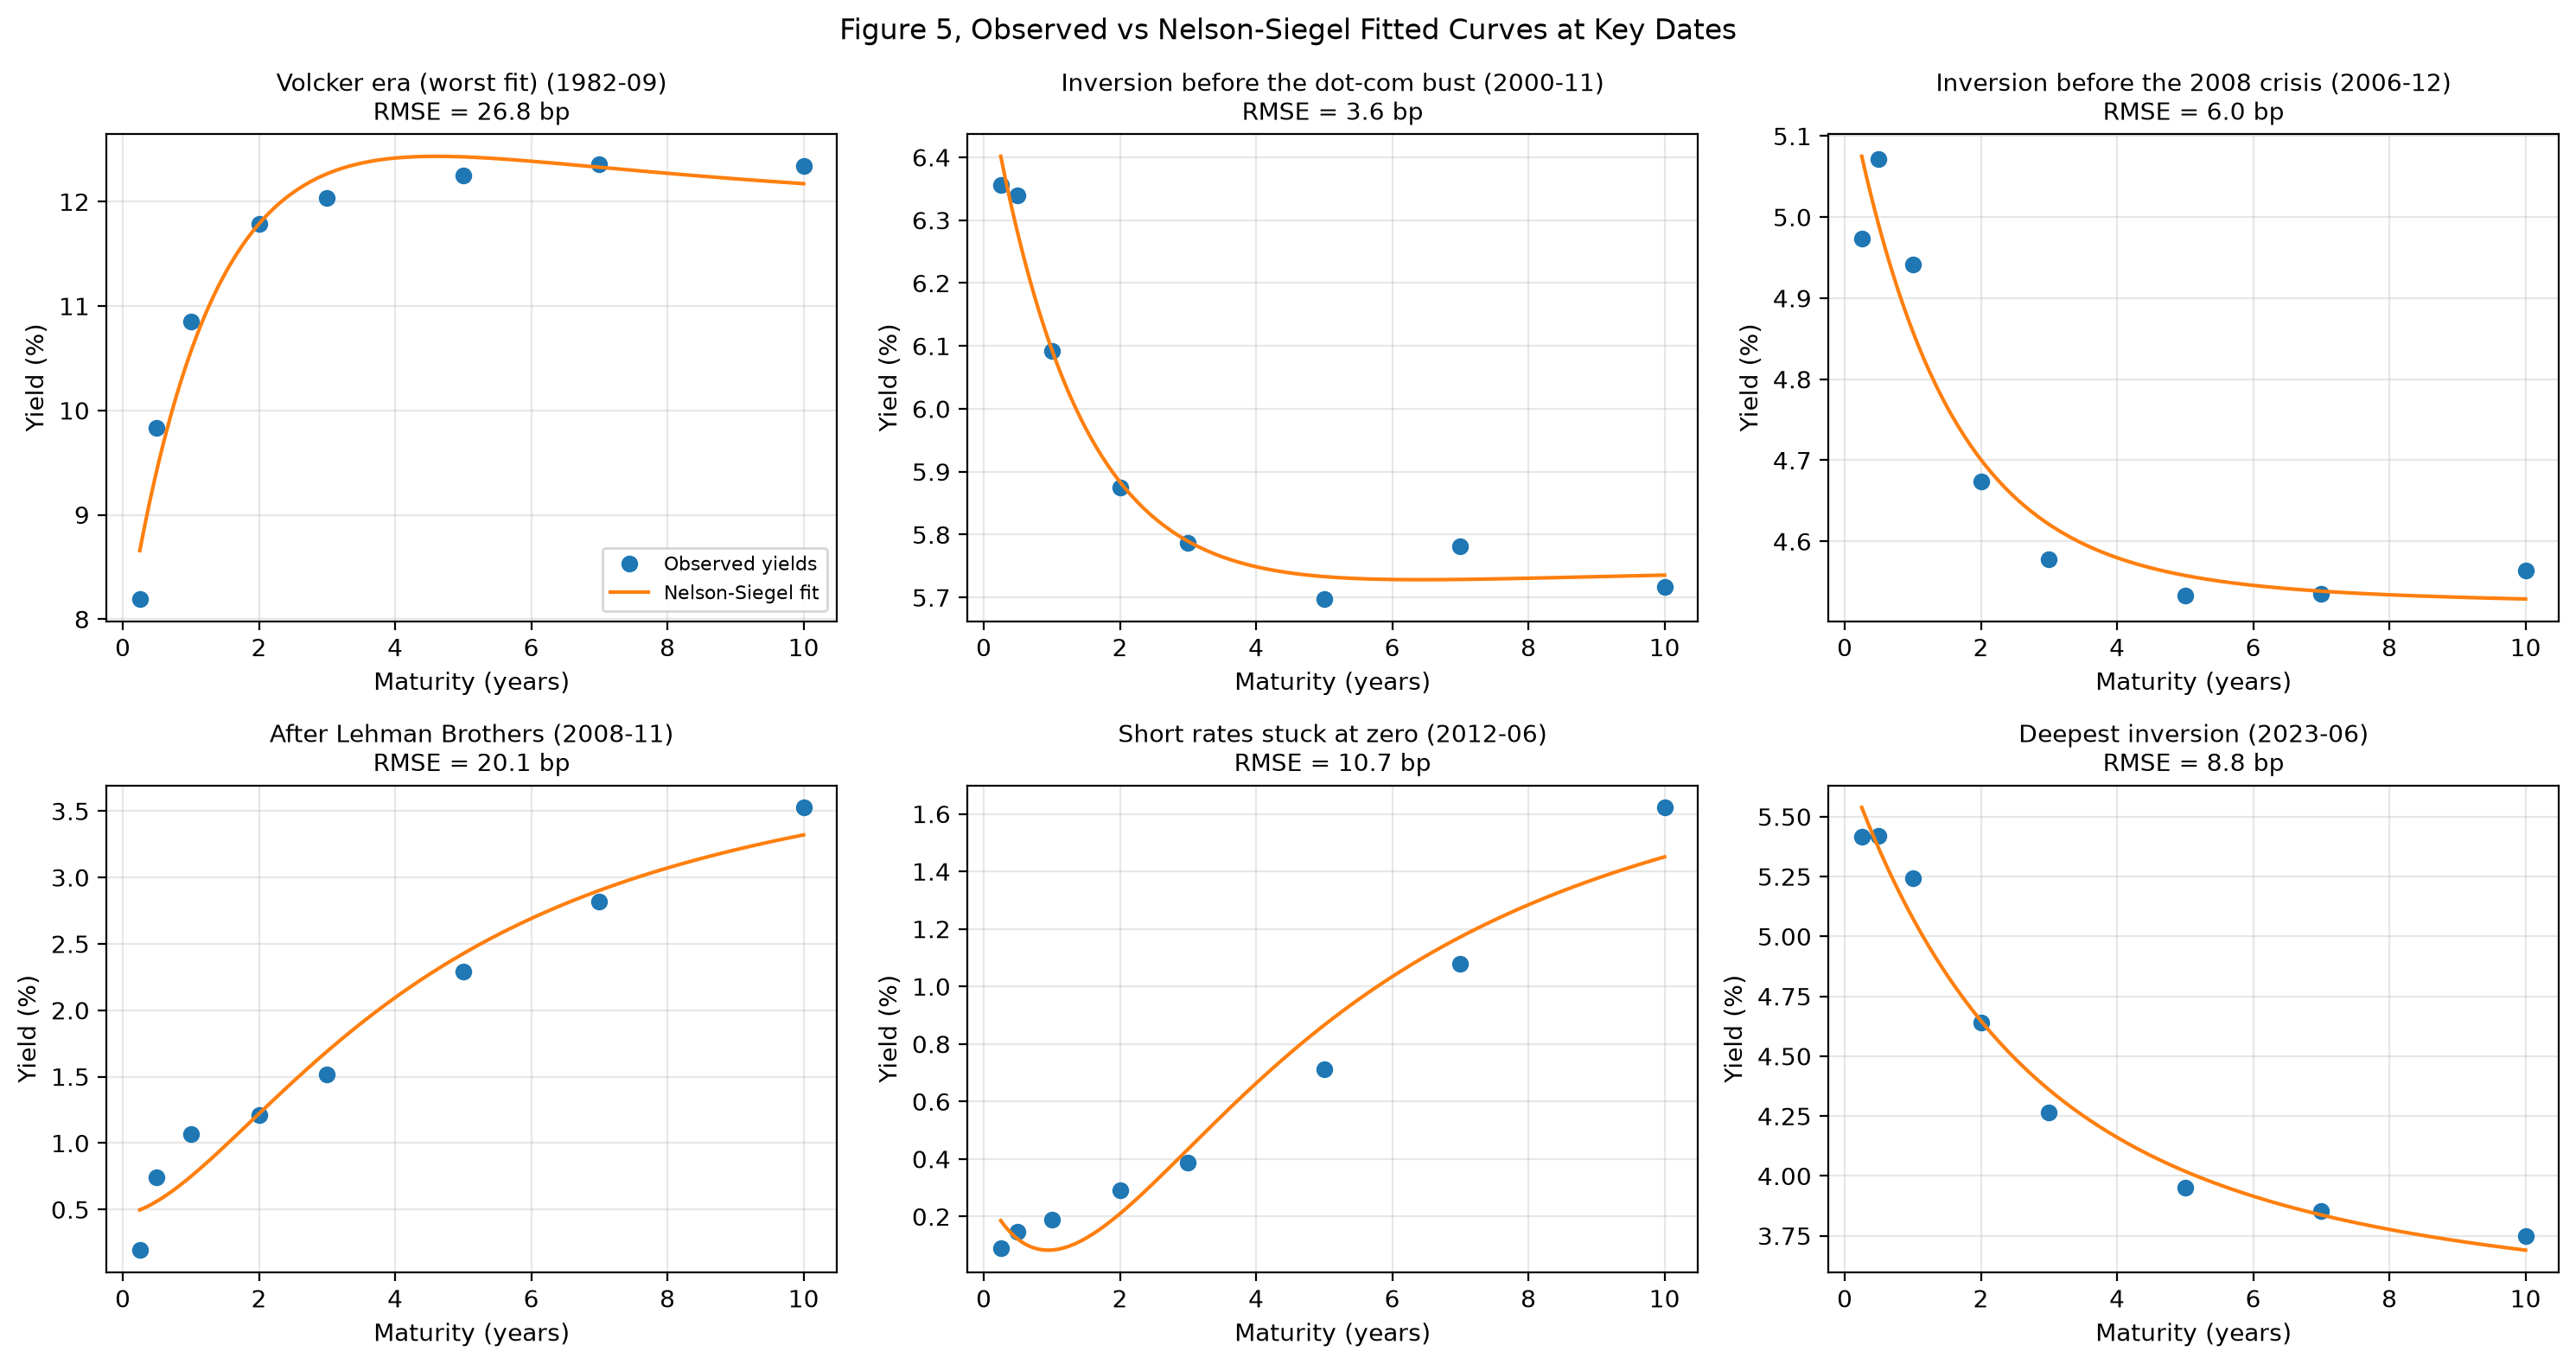

In [19]:
fig = plot_key_dates(yields, KEY_DATES)
fig.savefig("assets/figure5_key_dates.png", bbox_inches="tight")
plt.show()

### Fitted curves at key dates (Figure 5)

The six panels show the observed curve and the Nelson-Siegel fit at moments that each tell a different story:

- **Clean shapes are fitted very well.** The November 2000 inversion is captured with an RMSE of only 3.6 bp (0.036%), and the deep June 2023 inversion with 8.8 bp (0.088%).
- **Kinks at the short end are not.** In September 1982 (26.8 bp), the 3-month yield had collapsed to about 8.2% while long yields stayed near 12%. In November 2008 (20.1 bp), the flight to safety after Lehman Brothers pushed the 3-month yield down to about 0.2%, far below the 6-month and 1-year yields. In December 2006, a small hump at 6 months is smoothed away.
- **The zero floor is a blind spot.** In June 2012 (10.7 bp), the fitted curve dips below the observed yields around 1 year, then overshoots around 5 years: the model has no notion of a lower bound at zero.

**Pattern:** nearly all large errors come from the 3-month to 1-year segment, where Fed decisions and flights to safety hit first. A smooth three-factor shape with a fixed λ cannot follow sudden kinks there.

## 8. Key findings

| # | Finding | Evidence |
|---|---------|----------|
| 1 | **Three factors describe 44 years of the US yield curve** | Median fit error of 4.4 bp (0.044%) over 537 months; 75% of months below 6.4 bp (0.064%) |
| 2 | **The factors mean what they claim** | Correlation with observed measures: level 0.988, slope 0.992, curvature 0.998 (Figure 4) |
| 3 | **Inversions are rare** | The curve is inverted (β₁ > 0) in only 11.5% of months, about one month in nine |
| 4 | **Inversions came before recessions** | Inverted slope in 2000, 2006–2007 and 2019, ahead of the 2001, 2008 and 2020 recessions; the deepest inversion (2022–2024, β₁ up to +2.39 pp) was not followed by a recession (Figure 2) |
| 5 | **Four decades of falling rates, then a rebound** | The level fell from 14.14% (1982) to 0.84% (2020), then rose back to 5.03% in September 2026 |
| 6 | **The model's weak spot is the short end** | Clean shapes fit very well (3.6 bp in November 2000), but sudden kinks between 3 months and 1 year do not: 26.8 bp in September 1982, 20.1 bp in November 2008, 10.7 bp in June 2012 when short rates were stuck at zero (Figures 3 and 5) |

**Takeaway:** a simple three-factor model with a fixed λ is enough to summarise the US yield curve and to read the business cycle through its slope. Its main limit sits at the short end, where Fed decisions, flights to safety and the zero lower bound can bend the curve faster than a smooth three-factor shape can follow.

In [23]:
yields.to_json("pour la video")